<a href="https://colab.research.google.com/github/nyosef1108/multilayer-perceptron-from-scratch/blob/main/DEMO2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Starting Training (Wide-Gap Spiral)...
Epoch    0: Loss = 0.2693, Accuracy = 47.7%
Epoch  100: Loss = 0.2540, Accuracy = 48.2%
Epoch  200: Loss = 0.2522, Accuracy = 50.7%
Epoch  300: Loss = 0.2303, Accuracy = 56.3%
Epoch  400: Loss = 0.1690, Accuracy = 70.0%
Epoch  500: Loss = 0.1120, Accuracy = 81.8%
Epoch  600: Loss = 0.0996, Accuracy = 86.7%
Epoch  700: Loss = 0.0812, Accuracy = 89.2%
Epoch  800: Loss = 0.0313, Accuracy = 96.0%
Epoch  900: Loss = 0.0199, Accuracy = 97.5%
Epoch 1000: Loss = 0.0080, Accuracy = 99.3%
Epoch 1100: Loss = 0.0106, Accuracy = 98.7%
Epoch 1200: Loss = 0.0058, Accuracy = 99.3%
Epoch 1300: Loss = 0.0028, Accuracy = 100.0%
Epoch 1400: Loss = 0.0276, Accuracy = 96.8%
Epoch 1500: Loss = 0.0048, Accuracy = 99.8%
Epoch 1600: Loss = 0.0031, Accuracy = 99.8%
Epoch 1700: Loss = 0.0036, Accuracy = 99.8%
Epoch 1800: Loss = 0.0022, Accuracy = 99.8%
Epoch 1900: Loss = 0.0013, Accuracy = 100.0%
Epoch 2000: Loss = 0.0018, Accuracy = 99.8%


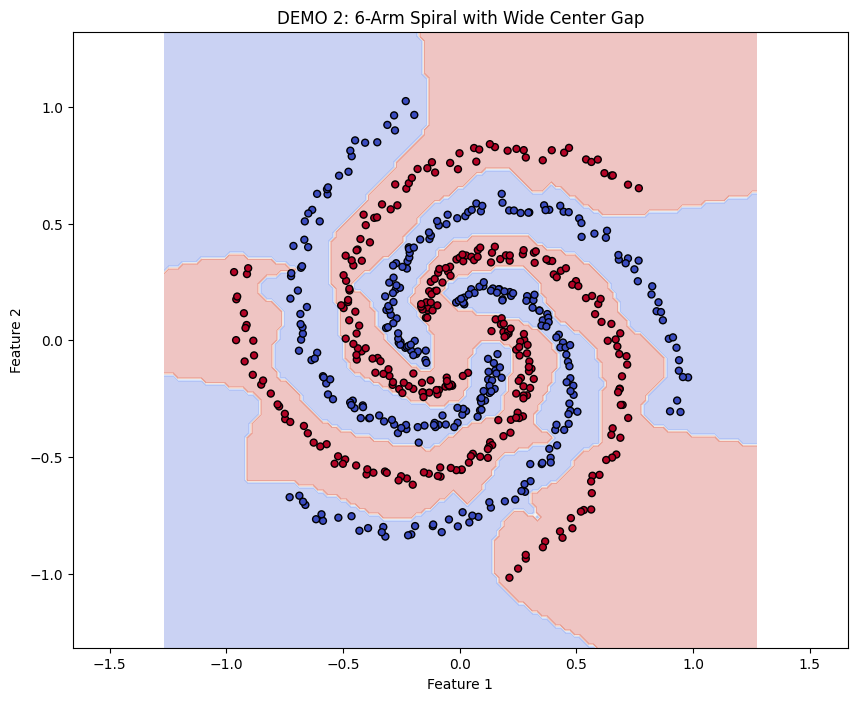

In [5]:
# DEMO 2: Wide-Gap 6-Arm Spiral
# Architecture: 2 Input -> 10 Hidden -> 10 Hidden -> 1 Output

# 1. Install the package
!pip install multilayer-perceptron-from-scratch

import numpy as np
import matplotlib.pyplot as plt
from multilayer_perceptron import Network

# --- Function to generate CLEAR SPIRAL with a wide center gap ---
def generate_wide_gap_spiral(n_samples=150, n_arms=6, noise=0.02):
    X = []
    y = []

    arm_angles = np.linspace(0, 2 * np.pi, n_arms, endpoint=False)

    for i, start_angle in enumerate(arm_angles):
        # 1. Start from r=0.3 to create a massive gap in the center
        # 2. Use a power of 1.5 to push points further out faster
        r = np.linspace(0.3, 1.0, n_samples)**1.5

        # Spiral rotation
        t = np.linspace(0, 4.0, n_samples) + start_angle

        # Calculate coordinates
        x_arm = r * np.sin(t) + np.random.randn(n_samples) * noise
        y_arm = r * np.cos(t) + np.random.randn(n_samples) * noise

        X.append(np.c_[x_arm, y_arm])
        y.append(np.ones(n_samples) * (i % 2))

    return np.vstack(X), np.hstack(y)

# --- Execution ---

# 1. Generate data
X, y = generate_wide_gap_spiral(n_samples=100, n_arms=6)
training_data = [(xi.reshape(2, 1), np.array([[float(yi)]])) for xi, yi in zip(X, y)]

# 2. Initialize the Network (2 Hidden layers, 10 neurons each)
mlp = Network([2, 10, 10, 1])

# 3. Train the Network
print("Starting Training (Wide-Gap Spiral)...")
# Learning rate 0.2 to handle the sharper transitions
mlp.SGD(training_data, epochs=2001, learning_rate=0.2)

# 4. Visualization
x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

Z = []
for p in np.c_[xx.ravel(), yy.ravel()]:
    out, _, _ = mlp.feedforward(p.reshape(2, 1))
    Z.append(1 if out >= 0.5 else 0)

Z = np.array(Z).reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=25)
plt.title("DEMO 2: 6-Arm Spiral with Wide Center Gap")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.axis('equal') # Maintain proportions
plt.show()